# DVP03: Full Stack Analytics - Database to Visualization

El análisis de datos real rara vez ocurre en un solo archivo CSV. En este proyecto, nos conectaremos a un motor relacional MySQL, realizaremos uniones complejas (`JOINs` lógicos) con Pandas, y crearemos visualizaciones estratégicas.

**Buena práctica aprendida:** Aprenderemos a seleccionar el tipo de gráfico correcto. Por ejemplo, nunca debemos usar gráficos de líneas para comparar categorías discretas; las líneas son para series de tiempo.

In [ ]:
import pandas as pd
import matplotlib.pyplot as plt
from sqlalchemy import create_engine
from sqlalchemy.engine import URL

# 1. Configurar conexión (Usa .env en proyectos reales)
connection_url = URL.create(
    drivername="mysql+pymysql",
    username='root',
    password='',
    host='localhost',
    port=3306,
    database='RestauranteDB'
)

# 2. Inicializar motor y cargar las tablas principales
engine = create_engine(connection_url)

df_clientes = pd.read_sql('SELECT * FROM clientes', con=engine)
df_platos = pd.read_sql('SELECT * FROM platos', con=engine)
df_categorias = pd.read_sql('SELECT * FROM categorias', con=engine)
df_pedidos = pd.read_sql('SELECT * FROM pedidos', con=engine)
df_detalle = pd.read_sql('SELECT * FROM detalle_pedido', con=engine)

print("Datos extraídos exitosamente de MySQL.")

Datos extraídos exitosamente de MySQL.


## 1. Top Customers Analysis (Bar Chart)
Para visualizar a nuestros mejores clientes, primero debemos unir (`merge`) los pedidos, los detalles y la información del cliente, calculando el subtotal gastado.

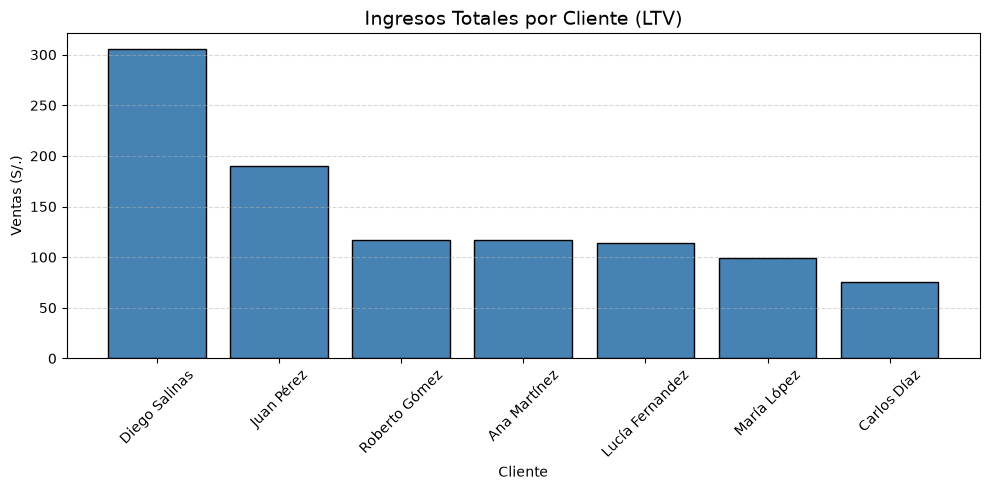

In [2]:
# Unir Pedidos con Clientes y Detalles
df_ventas = pd.merge(df_pedidos, df_clientes, on='id_cliente', how='inner')
df_ventas = pd.merge(df_ventas, df_detalle, on='id_pedido', how='inner')

# Calcular subtotal (Cantidad * Precio Unitario)
df_ventas['subtotal'] = df_ventas['cantidad'] * df_ventas['precio_unitario']

# Agrupar por cliente
df_total_clientes = (
    df_ventas.groupby(['id_cliente', 'nombre'], as_index=False)
    .agg(total_ventas=('subtotal', 'sum'))
    .sort_values(by='total_ventas', ascending=False)
)

# Gráfico de Barras Verticales
plt.figure(figsize=(10,5))
plt.bar(df_total_clientes['nombre'], df_total_clientes['total_ventas'], color='steelblue', edgecolor='black')

plt.title('Ingresos Totales por Cliente (LTV)', fontsize=14)
plt.xlabel('Cliente')
plt.ylabel('Ventas (S/.)')
plt.xticks(rotation=45)
plt.grid(axis='y', linestyle='--', alpha=0.5)

plt.tight_layout()
plt.show()

## 2. Order Volume Distribution (Histogram)
Un histograma nos ayuda a entender la distribución de las cantidades vendidas de nuestros platos. ¿Vendemos mayormente platos en pocas cantidades o en grandes volúmenes?

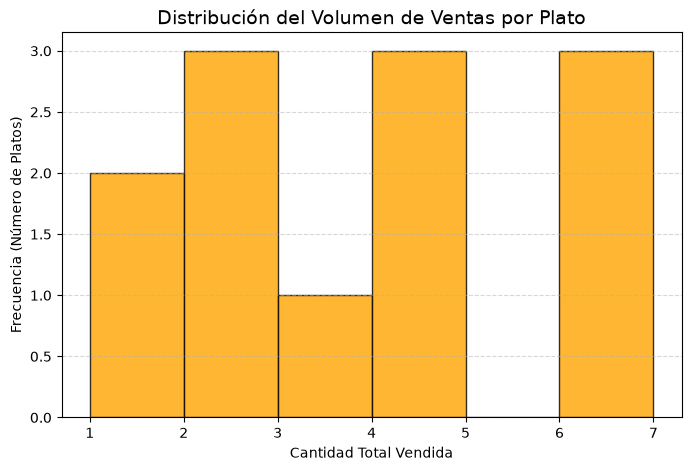

In [3]:
# Agrupar por plato
df_platos_vendidos = df_ventas.groupby('id_plato')['cantidad'].sum().reset_index()

plt.figure(figsize=(8,5))
plt.hist(
    df_platos_vendidos['cantidad'], 
    bins=6, 
    color='orange', 
    edgecolor='black',
    alpha=0.8
)

plt.title('Distribución del Volumen de Ventas por Plato', fontsize=14)
plt.xlabel('Cantidad Total Vendida')
plt.ylabel('Frecuencia (Número de Platos)')
plt.grid(axis='y', linestyle='--', alpha=0.5)

plt.show()

## 3. Sales by Category (Horizontal Bar Chart)
*Nota Didáctica:* Un error común en principiantes es usar gráficos de líneas para datos categóricos (como nombres de categorías). Las líneas denotan continuidad. Para comparar categorías, un gráfico de **barras horizontales** es mucho más limpio y legible.

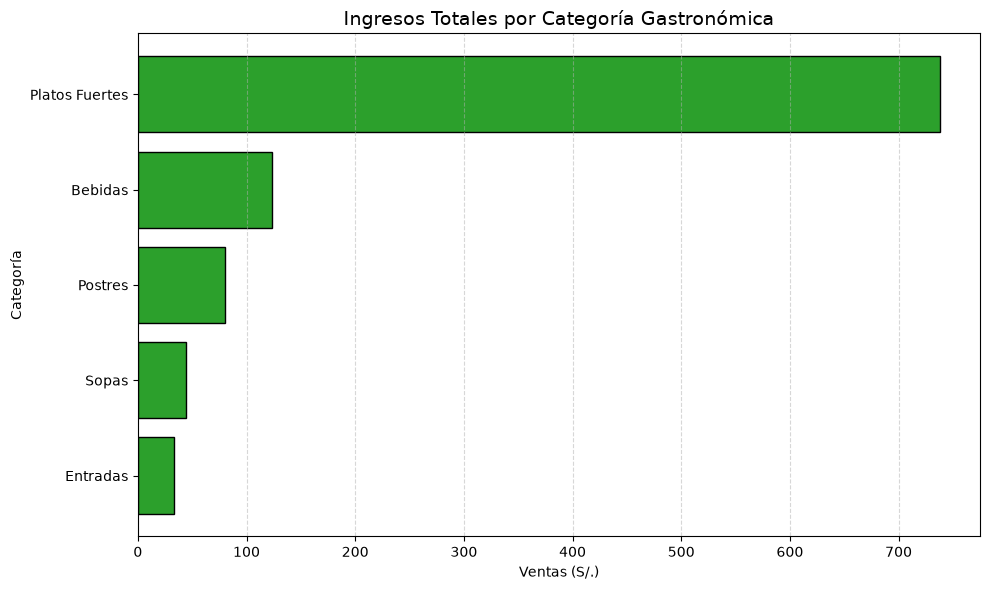

In [4]:
# Unir Detalles con Platos y Categorías
df_cat = pd.merge(df_detalle, df_platos, on='id_plato', how='inner')
df_cat = pd.merge(df_cat, df_categorias, on='id_categoria', how='inner')

df_cat['subtotal'] = df_cat['cantidad'] * df_cat['precio_unitario']

# Agrupar por categoría
df_total_categoria = (
    df_cat.groupby('nombre_y', as_index=False)['subtotal']
    .sum()
    .rename(columns={'nombre_y': 'categoria', 'subtotal': 'total_ventas'})
    .sort_values(by='total_ventas', ascending=True) # Ascendente para que el mayor quede arriba en barh
)

# Gráfico de Barras Horizontales
plt.figure(figsize=(10,6))
plt.barh(df_total_categoria['categoria'], df_total_categoria['total_ventas'], color='#2ca02c', edgecolor='black')

plt.title('Ingresos Totales por Categoría Gastronómica', fontsize=14)
plt.xlabel('Ventas (S/.)')
plt.ylabel('Categoría')
plt.grid(axis='x', linestyle='--', alpha=0.5)

plt.tight_layout()
plt.show()